# Detecting Anomalous Transactions

Fraud costs more than money: it costs customer trust. This notebook scans 2,512 bank transactions for the ones that look unusual enough to deserve a fraud analyst's attention.

* **Part A** follows the four steps of DataCamp's guided project *Detecting Anomalous Transactions*: compute anomaly scores with an Isolation Forest, flag anomalies, summarise them, and visualise the scores.
* **Part B** goes further: univariate baselines, two more detectors (KNN, LOF), an ensemble with human-readable reason codes, and an **evaluation with planted anomalies**, because the data has no fraud labels.

**Data:** [Bank Transaction Dataset for Fraud Detection](https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection) by Vala Khorasani (Kaggle, Apache-2.0). Shared logic lives in `detect.py` and is reused by the Streamlit app and the tests.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyod.models.iforest import IForest
from pyod.models.mad import MAD
from scipy.special import erf
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import RobustScaler

from detect import FEATURES, add_features, explain, flag, score

Path("images").mkdir(exist_ok=True)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})
GREY, RED, BLUE = "#9aa5b1", "#d1495b", "#577590"

## 0. Load and sanity-check the data

In [2]:
raw = pd.read_csv("data/bank_transactions_data_2.csv", parse_dates=["TransactionDate", "PreviousTransactionDate"])
print(raw.shape)
print("missing values:", raw.isna().sum().sum(), "| duplicate rows:", raw.duplicated().sum())
raw.head()

(2512, 16)
missing values: 0 | duplicate rows: 0


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [3]:
late = (raw["PreviousTransactionDate"] > raw["TransactionDate"]).mean()
print(f"PreviousTransactionDate later than TransactionDate: {late:.0%} of rows")
print("PreviousTransactionDate range:", raw["PreviousTransactionDate"].min(), "->", raw["PreviousTransactionDate"].max())
print("Hours of day seen:", sorted(raw["TransactionDate"].dt.hour.unique().tolist()))

per_account = raw.groupby("AccountID").agg(
    n=("TransactionID", "size"), devices=("DeviceID", "nunique"), ips=("IP Address", "nunique")
)
multi = per_account[per_account["n"] > 1]
print(f"Accounts with >1 transaction where every transaction uses a new device: {(multi['devices'] == multi['n']).mean():.0%}")
print(f"... and a new IP address: {(multi['ips'] == multi['n']).mean():.0%}")

PreviousTransactionDate later than TransactionDate: 100% of rows
PreviousTransactionDate range: 2024-11-04 08:06:23 -> 2024-11-04 08:12:23
Hours of day seen: [16, 17, 18]
Accounts with >1 transaction where every transaction uses a new device: 97%
... and a new IP address: 97%


**Data-quality findings that shape the features:**

* `PreviousTransactionDate` falls *after* the transaction on every row (it looks like the dataset's generation time), so "time since last transaction" can't be computed.
* Transactions only happen between 16:00 and 18:59, so time of day carries no signal.
* Device and IP change on almost every transaction of an account, so "new device" or "new IP" can't separate normal from suspicious.

That leaves behavioural numbers: **amount, duration, login attempts**, plus two context ratios built in `detect.add_features`:

* `amount_to_balance` = amount ÷ balance after the transaction (draining an account looks very different from a coffee).
* `amount_vs_account_median` = amount ÷ that account's usual amount (10× your normal spend is odd even if the dollar figure is ordinary).

Age, occupation and raw balance are left out on purpose: they describe the *customer*, not the *transaction*, and using them would flag people for being old or wealthy.

---
## Part A: the DataCamp project (Isolation Forest)

### Step 1. Computing anomaly scores
An Isolation Forest builds random trees that split the data at random values. Unusual points get isolated in very few splits, so a short average path length means a high anomaly score. Features are put on a comparable scale with `RobustScaler` (median/IQR), which outliers can't distort.

Raw scores are hard to read, so we also convert them to an **outlier probability** with PyOD's *unify* method: standardise the scores, then pass them through the Gaussian error function.

In [4]:
df = add_features(raw)
df[FEATURES].describe().round(2)

,TransactionAmount,TransactionDuration,LoginAttempts,amount_to_balance,amount_vs_account_median
count,2512.00,2512.00,2512.00,2512.00,2512.00
mean,297.59,119.64,1.12,0.20,1.42
std,291.95,69.96,0.60,0.51,1.75
min,0.26,10.00,1.00,0.00,0.00
25%,81.89,63.00,1.00,0.02,0.47
50%,211.14,112.50,1.00,0.05,1.00
75%,414.53,161.00,1.00,0.15,1.66
max,1919.11,300.00,5.00,7.90,35.74


In [5]:
def to_probability(scores):
    """PyOD's 'unify' scaling: standardise, then erf -> outlier probability in 0..1."""
    scores = np.asarray(scores, dtype=float)
    return erf((scores - scores.mean()) / (scores.std() * np.sqrt(2))).clip(0, 1)


X = RobustScaler().fit_transform(df[FEATURES])
iforest = IForest(contamination=0.02, random_state=42).fit(X)

df["anomaly_score"] = iforest.decision_scores_
df["anomaly_prob"] = to_probability(iforest.decision_scores_)
df.sort_values("anomaly_score", ascending=False)[
    ["TransactionID", "TransactionAmount", "LoginAttempts", "TransactionDuration", "amount_to_balance", "anomaly_score", "anomaly_prob"]
].head().round(3)

,TransactionID,TransactionAmount,LoginAttempts,TransactionDuration,amount_to_balance,anomaly_score,anomaly_prob
274,TX000275,1176.28,5,174,3.634,0.115,1.0
934,TX000935,1022.75,1,158,4.923,0.102,1.0
2086,TX002087,1192.95,1,73,3.669,0.101,1.0
898,TX000899,1531.31,4,62,1.781,0.090,1.0
1213,TX001214,1192.20,5,103,0.153,0.088,1.0


### Step 2. Flagging transactions as anomalies
`contamination=0.02` tells the model to expect about 2% anomalies, so it puts its threshold at the 98th percentile of scores and labels everything above it. That 2% is really a business choice: roughly how many transactions the fraud team can review.

In [6]:
df["is_anomaly"] = iforest.labels_.astype(bool)
print(f"Flagged by the 2% contamination threshold: {df['is_anomaly'].sum()} of {len(df)} ({df['is_anomaly'].mean():.1%})")
print(f"Flagged if we used 'outlier probability > 0.75' instead: {(df['anomaly_prob'] > 0.75).sum()} ({(df['anomaly_prob'] > 0.75).mean():.0%})")

Flagged by the 2% contamination threshold: 51 of 2512 (2.0%)
Flagged if we used 'outlier probability > 0.75' instead: 327 (13%)


A fixed probability cut-off would send about **six times more** transactions to review. The probabilities aren't wrong, but they bunch up near 1, so they don't map to a workload. Flagging by **capacity** (the top N) is the more practical rule, and it's what the app does.

### Step 3. Summary of anomalous transactions

In [7]:
summary = df.groupby("is_anomaly")[FEATURES].median().T
summary.columns = ["normal (median)", "anomalous (median)"]
summary["ratio"] = summary["anomalous (median)"] / summary["normal (median)"]
summary.round(2)

,normal (median),anomalous (median),ratio
TransactionAmount,205.58,879.25,4.28
TransactionDuration,112.00,139.00,1.24
LoginAttempts,1.00,1.00,1.00
amount_to_balance,0.05,1.63,32.09
amount_vs_account_median,1.00,4.38,4.38


In [8]:
for col, label in [("LoginAttempts", "more than 1 login attempt"), ("amount_to_balance", "amount above the remaining balance")]:
    hit = df[col] > 1
    print(f"Share with {label}: normal {hit[~df['is_anomaly']].mean():.0%} | anomalous {hit[df['is_anomaly']].mean():.0%}")
pd.crosstab(df["Channel"], df["is_anomaly"], normalize="columns").round(2).rename(columns={False: "normal", True: "anomalous"})

Share with more than 1 login attempt: normal 4% | anomalous 25%
Share with amount above the remaining balance: normal 3% | anomalous 65%


is_anomaly,normal,anomalous
Channel,,
ATM,0.33,0.33
Branch,0.34,0.37
Online,0.32,0.29


Anomalous transactions are about 4× larger than usual, both in dollars and against the account's own habits. Two-thirds of them exceed the balance left afterwards, and one in four had repeated login attempts. Channel makes no difference.

### Step 4. Visualising the results with a histogram

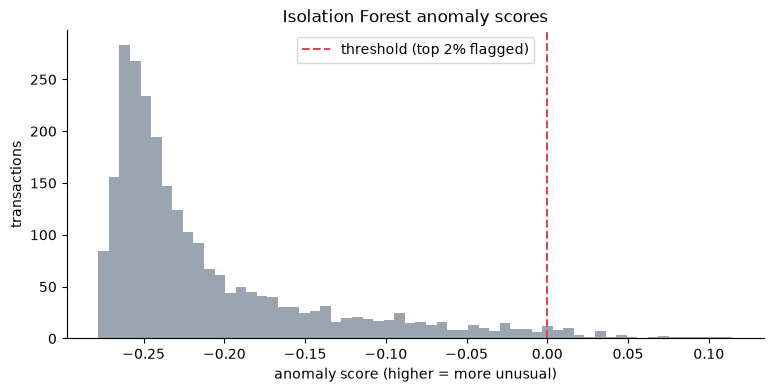

In [9]:
fig, ax = plt.subplots()
ax.hist(df["anomaly_score"], bins=60, color=GREY)
ax.axvline(iforest.threshold_, color=RED, linestyle="--", label="threshold (top 2% flagged)")
ax.set(title="Isolation Forest anomaly scores", xlabel="anomaly score (higher = more unusual)", ylabel="transactions")
ax.legend()
fig.savefig("images/score_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

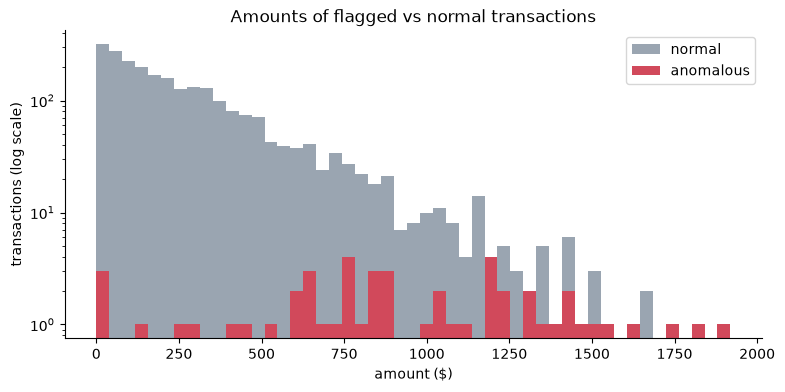

In [10]:
fig, ax = plt.subplots()
bins = np.linspace(0, df["TransactionAmount"].max(), 50)
ax.hist(df.loc[~df["is_anomaly"], "TransactionAmount"], bins=bins, color=GREY, label="normal")
ax.hist(df.loc[df["is_anomaly"], "TransactionAmount"], bins=bins, color=RED, label="anomalous")
ax.set(title="Amounts of flagged vs normal transactions", xlabel="amount ($)", ylabel="transactions (log scale)", yscale="log")
ax.legend()
plt.show()

The score distribution has a long right tail, and the threshold cuts off its end. The flagged transactions are *not* simply the biggest amounts: many have ordinary amounts but unusual login attempts, durations or ratios. That's the advantage of a multivariate model over a single-column rule, which Part B measures.

---
## Part B: extensions

### 5. Univariate baselines on amount
The classic one-column rules from the course: IQR fences, z-score, and the modified z-score (median absolute deviation, PyOD's `MAD`).

In [11]:
amount = df["TransactionAmount"]
q1, q3 = amount.quantile([0.25, 0.75])
iqr_flag = (amount < q1 - 1.5 * (q3 - q1)) | (amount > q3 + 1.5 * (q3 - q1))
z_flag = ((amount - amount.mean()) / amount.std()).abs() > 3
mad_flag = pd.Series(MAD(threshold=3.5).fit(amount.to_frame()).labels_.astype(bool), index=df.index)

for name, f in {"IQR 1.5x": iqr_flag, "z-score > 3": z_flag, "modified z (MAD) > 3.5": mad_flag}.items():
    print(f"{name:24} flags {f.sum():3}, of which {(f & df['is_anomaly']).sum():2} are also flagged by the Isolation Forest")

IQR 1.5x                 flags 113, of which 24 are also flagged by the Isolation Forest
z-score > 3              flags  48, of which 19 are also flagged by the Isolation Forest
modified z (MAD) > 3.5   flags 100, of which 24 are also flagged by the Isolation Forest


Amount-only rules see one dimension. They flag every large-but-normal purchase and are blind to a modest transfer made after five failed logins. Fewer than half of their flags overlap with the Isolation Forest's.

### 6. Multivariate detectors: KNN and LOF next to Isolation Forest
* **KNN**: far from its nearest neighbours means unusual.
* **LOF** (Local Outlier Factor): sparser than its own neighbourhood means unusual, which also catches points that are odd only *locally*.

`detect.score` fits all three and standardises each one's raw scores into **z-scores** (standard deviations above the average transaction), so they're on the same scale. How much do the three agree on the top 2%?

In [12]:
scores = score(df)
top = {name: set(df.index[flag(scores[name], 0.02)]) for name in ["iforest", "knn", "lof"]}
pairs = [("iforest", "knn"), ("iforest", "lof"), ("knn", "lof")]
pd.DataFrame(
    {"shared alerts": [len(top[a] & top[b]) for a, b in pairs],
     "Jaccard overlap": [len(top[a] & top[b]) / len(top[a] | top[b]) for a, b in pairs]},
    index=[f"{a} vs {b}" for a, b in pairs],
).round(2)

,shared alerts,Jaccard overlap
iforest vs knn,38,0.61
iforest vs lof,19,0.23
knn vs lof,22,0.28


Isolation Forest and KNN agree on most alerts. LOF sees something different: it looks for *local* density changes, and this data is fairly uniform. Averaging the three z-scores (an **ensemble**) keeps any one model's quirks from dominating.

### 7. Ensemble alerts with reason codes
An alert an analyst can't understand is just an expensive guess. `detect.explain` names the two features where each transaction sits furthest from typical, shown as percentiles (p100 = most extreme in the data, p0 = lowest).

In [13]:
df = df.join(scores)
df["flagged"] = flag(df["ensemble"], alert_rate=0.02)
df["reason"] = explain(df)
alerts = df[df["flagged"]].sort_values("ensemble", ascending=False)
alerts[["TransactionID", "AccountID", "TransactionAmount", "LoginAttempts", "TransactionDuration", "AccountBalance", "ensemble", "reason"]].head(10).round(2)

,TransactionID,AccountID,TransactionAmount,LoginAttempts,TransactionDuration,AccountBalance,ensemble,reason
1147,TX001148,AC00052,409.59,1,50,14563.02,13.83,"amount_vs_account_median p100, TransactionDura..."
2273,TX002274,AC00357,806.97,1,11,102.20,10.94,"amount_to_balance p100, TransactionDuration p0"
2191,TX002192,AC00131,879.25,1,137,125.85,7.88,"amount_to_balance p100, TransactionAmount p95"
855,TX000856,AC00217,1074.95,1,91,530.86,6.89,"amount_vs_account_median p100, amount_to_balan..."
1459,TX001460,AC00460,659.71,1,148,106.86,6.16,"amount_to_balance p100, TransactionAmount p89"
2295,TX002296,AC00138,61.40,2,20,7892.87,6.06,"TransactionDuration p4, LoginAttempts p96"
476,TX000477,AC00442,53.81,2,37,2564.62,5.67,"LoginAttempts p96, TransactionDuration p12"
327,TX000328,AC00434,870.43,1,55,10115.18,5.44,"amount_vs_account_median p100, TransactionAmou..."
1383,TX001384,AC00261,508.73,1,89,7640.57,5.23,"amount_vs_account_median p100, TransactionAmou..."
934,TX000935,AC00456,1022.75,1,158,207.74,5.18,"amount_to_balance p100, amount_vs_account_medi..."


In [14]:
# Which features drive the alerts?
alerts["reason"].str.split(", ").explode().str.split(" p").str[0].value_counts()

reason
amount_to_balance           25
LoginAttempts               24
amount_vs_account_median    22
TransactionAmount           15
TransactionDuration         14
Name: count, dtype: int64

### 8. How good is it? Evaluation with planted anomalies
Without fraud labels, "the model flagged 50 transactions" proves nothing. So we **plant** 27 synthetic frauds (~1%) of three types into the real data and check how well each method ranks them:

| type | what changes |
|---|---|
| account takeover | 4-5 login attempts, online channel, amount ×3-6 |
| big-ticket | amount = 5-10× that account's usual (median) amount |
| balance drain | amount = 90-100% of the funds available, so the account is left almost empty |

Metrics: **ROC-AUC** (how often a random planted fraud ranks above a random real transaction), **average precision** (area under the precision-recall curve, the honest metric when positives are rare), and **recall at a 2% alert rate** (the share of planted frauds the review team would actually see). 27 cases is a small test, so the whole experiment is **repeated with 20 random seeds** and reported as mean ± standard deviation.

In [15]:
KINDS = ["account takeover", "big-ticket", "balance drain"]
account_median = raw.groupby("AccountID")["TransactionAmount"].median()


def plant_anomalies(seed, n_each=9):
    """Copy random real transactions, turn them into the three fraud patterns, mix them back in."""
    rng = np.random.default_rng(seed)
    p = raw.sample(3 * n_each, random_state=seed).reset_index(drop=True)
    p["kind"] = np.repeat(KINDS, n_each)

    t = p["kind"] == "account takeover"
    p.loc[t, "LoginAttempts"] = rng.integers(4, 6, t.sum())
    p.loc[t, "Channel"] = "Online"
    p.loc[t, "TransactionAmount"] *= rng.uniform(3, 6, t.sum())

    b = p["kind"] == "big-ticket"
    p.loc[b, "TransactionAmount"] = p.loc[b, "AccountID"].map(account_median).to_numpy() * rng.uniform(5, 10, b.sum())

    d = p["kind"] == "balance drain"
    available = p.loc[d, "AccountBalance"] + p.loc[d, "TransactionAmount"]
    p.loc[d, "TransactionAmount"] = available * rng.uniform(0.9, 1.0, d.sum())
    p.loc[d, "AccountBalance"] = (available - p.loc[d, "TransactionAmount"]).clip(lower=1)
    p["TransactionID"] = [f"PLANTED_{i:02d}" for i in range(len(p))]

    mixed = add_features(pd.concat([raw.assign(kind="original"), p], ignore_index=True))
    return mixed, (mixed["kind"] != "original").astype(int)


mixed, y = plant_anomalies(seed=0)
print(f"{y.sum()} planted anomalies among {len(mixed)} transactions ({y.mean():.1%}). Examples:")
mixed[y == 1].groupby("kind").head(2)[["TransactionID", "kind", "TransactionAmount", "LoginAttempts", "AccountBalance", "amount_vs_account_median"]].round(2)

27 planted anomalies among 2539 transactions (1.1%). Examples:


,TransactionID,kind,TransactionAmount,LoginAttempts,AccountBalance,amount_vs_account_median
2512,PLANTED_00,account takeover,2908.21,5,2757.23,1.70
2513,PLANTED_01,account takeover,1228.69,5,2791.12,6.27
2521,PLANTED_09,big-ticket,849.61,1,9662.88,4.67
2522,PLANTED_10,big-ticket,1285.23,1,1876.35,4.35
2530,PLANTED_18,balance drain,1732.30,1,63.35,7.02
2531,PLANTED_19,balance drain,3889.30,1,155.57,30.29


In [16]:
def evaluate(mixed, y, seed):
    s = score(mixed, seed=seed)
    dev = (mixed["TransactionAmount"] - mixed["TransactionAmount"].median()).abs()
    candidates = {
        "amount only (robust z)": dev / dev.median(),
        "Isolation Forest": s["iforest"],
        "KNN": s["knn"],
        "LOF": s["lof"],
        "ensemble: mean of probabilities": pd.DataFrame({c: to_probability(s[c]) for c in ["iforest", "knn", "lof"]}, index=s.index).mean(axis=1),
        "ensemble: mean of z-scores": s["ensemble"],
    }
    rows = []
    for method, sc in candidates.items():
        alerted = flag(sc, 0.02)
        rows.append({
            "method": method,
            "ROC-AUC": roc_auc_score(y, sc),
            "avg precision": average_precision_score(y, sc),
            "recall @2%": alerted[y == 1].mean(),
            **{f"recall: {k}": alerted[mixed["kind"] == k].mean() for k in KINDS},
        })
    return rows


runs = pd.DataFrame([row for seed in range(20) for row in evaluate(*plant_anomalies(seed), seed)])
runs.groupby("method", sort=False)[["ROC-AUC", "avg precision", "recall @2%"]].agg(lambda s: f"{s.mean():.3f} ± {s.std():.3f}")

,ROC-AUC,avg precision,recall @2%
method,,,
amount only (robust z),0.914 ± 0.029,0.618 ± 0.067,0.652 ± 0.065
Isolation Forest,0.977 ± 0.006,0.636 ± 0.041,0.687 ± 0.067
KNN,0.968 ± 0.007,0.550 ± 0.036,0.620 ± 0.043
LOF,0.901 ± 0.028,0.405 ± 0.049,0.554 ± 0.046
ensemble: mean of probabilities,0.971 ± 0.009,0.556 ± 0.035,0.628 ± 0.056
ensemble: mean of z-scores,0.976 ± 0.007,0.613 ± 0.055,0.670 ± 0.061


In [17]:
# Recall at a 2% alert rate, by type of planted fraud (mean of 20 runs)
runs.groupby("method", sort=False)[[f"recall: {k}" for k in KINDS]].mean().round(2)

,recall: account takeover,recall: big-ticket,recall: balance drain
method,,,
amount only (robust z),0.43,0.70,0.82
Isolation Forest,0.74,0.34,0.97
KNN,0.54,0.32,1.00
LOF,0.47,0.19,1.00
ensemble: mean of probabilities,0.58,0.31,1.00
ensemble: mean of z-scores,0.67,0.34,1.00


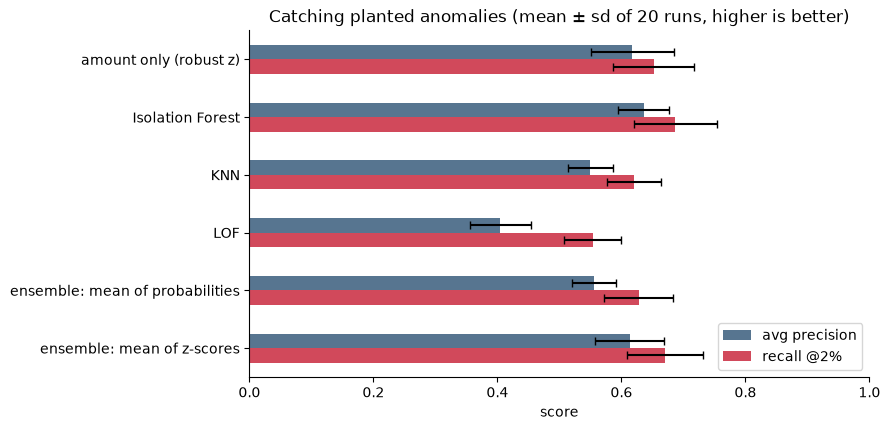

In [18]:
agg = runs.groupby("method", sort=False)[["avg precision", "recall @2%"]].agg(["mean", "std"])
ax = agg.xs("mean", axis=1, level=1).plot.barh(xerr=agg.xs("std", axis=1, level=1), color=[BLUE, RED], capsize=3, figsize=(8, 4.5))
ax.set(title="Catching planted anomalies (mean ± sd of 20 runs, higher is better)", xlim=(0, 1), xlabel="score", ylabel="")
ax.invert_yaxis()
ax.legend(loc="lower right")
ax.figure.savefig("images/method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Findings

**What the data says**
* About 2% of transactions (51) stand out. Compared with normal ones they are ~4× larger in dollars and ~4× larger than the account's own usual spend. 65% exceed the balance left afterwards, and 25% came after repeated login attempts. Channel makes no difference.
* The ensemble's reason codes are spread across all five features, so no single hand-written rule would catch every alert.

**What the evaluation says** (20 runs, 27 planted frauds each)
* Multivariate models rank far better overall than an amount-only rule: ROC-AUC **0.977** for the Isolation Forest vs **0.914** for amount only.
* **Isolation Forest, the DataCamp project's method, is the strongest single detector**: average precision 0.64, and 69% of planted frauds land in the 2% review queue. LOF is the weakest (0.41).
* **How you combine detectors matters.** Averaging z-scores (AP 0.61) beats averaging probabilities (0.56), because probabilities bunch up near 1 and tie the top of the ranking. The z-score ensemble scores within noise of the Isolation Forest alone, so it's kept for robustness on new data, not because it scores higher here.
* **Different methods catch different fraud.** The models catch account takeovers (Isolation Forest 74% vs 43% for amount only) and balance drains (~100%). The amount-only rule catches more big-ticket purchases (70% vs 34%), because the multivariate models spread one strong signal across five features.

**Recommendations**
1. Fill the review queue from the ensemble ranking at the team's capacity (here 2% ≈ 50 transactions) rather than with a fixed probability cut-off. "Probability > 0.75" would flag 13%.
2. Pair the model with a few hard rules for patterns it under-weights, such as *amount > 5× the account's median*. Combining rules and models is how production fraud systems work.
3. Show the reason codes with every alert so analysts can triage fast, and record their verdicts as labels for a future supervised model.

**Limitations**
* The dataset is synthetic and unlabelled, so there is no ground-truth fraud. The planted anomalies encode our assumptions about what fraud looks like, so the evaluation measures "catches these patterns", not real-world recall.
* Real anomalies may hide among the "normal" rows, which makes the measured precision pessimistic.
* Accounts have only about 5 transactions each, so per-account baselines (medians) are noisy.